<a href="https://colab.research.google.com/github/seth783/house-prediction-model/blob/main/HOUSE_RDICTION_MODEL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas
!pip install numpy
!pip install seaborn
!pip install matplotlib
!pip install sklearn
!pip install xgboost
!pip install joblib
!pip install pyforest
!pip install skikit_learn
!pip install scipy
!pip install plotly

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
ERROR: Could not find a version that satisfies the requirement skikit_learn (from versions: none)
ERROR: No matching distribution found for skikit_learn


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('/content/housedata.csv')

In [ ]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [ ]:
df.tail()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0
505,0.04741,0.0,11.93,0,0.573,6.030,80.8,2.5050,1,273,21.0,396.90,7.88,11.9


In [ ]:
df.shape

(506, 14)

In [ ]:
df.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

In [ ]:
df['MEDV'].describe()

,MEDV
count,506.000000
mean,22.532806
std,9.197104
min,5.000000
25%,17.025000
50%,21.200000
75%,25.000000
max,50.000000


In [ ]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [ ]:
df.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [ ]:
missing = df.isnull().mean()*100
missing.sort_values(ascending=False)

,0
CRIM,0.0
ZN,0.0
INDUS,0.0
CHAS,0.0
NOX,0.0
RM,0.0
AGE,0.0
DIS,0.0
RAD,0.0
TAX,0.0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dtypes

,0
CRIM,float64
ZN,float64
INDUS,float64
CHAS,int64
NOX,float64
RM,float64
AGE,float64
DIS,float64
RAD,int64
TAX,int64


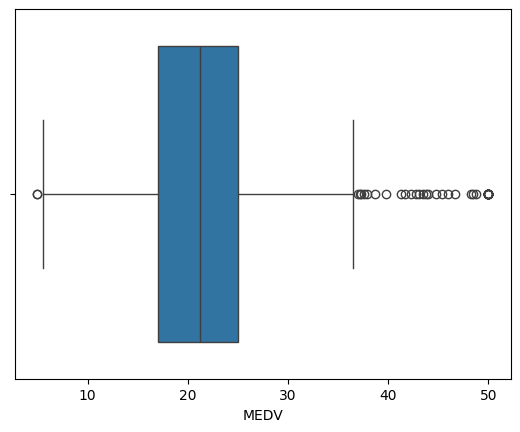

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df["MEDV"])
plt.show()

In [ ]:
Q1 = df["MEDV"].quantile(0.25)
Q3 = df["MEDV"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["MEDV"] < lower) | (df["MEDV"] > upper)]

print("Number of outliers:", len(outliers))
outliers.head()

Number of outliers: 40


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
97,0.12083,0.0,2.89,0,0.445,8.069,76.0,3.4952,2,276,18.0,396.90,4.21,38.7
98,0.08187,0.0,2.89,0,0.445,7.820,36.9,3.4952,2,276,18.0,393.53,3.57,43.8
157,1.22358,0.0,19.58,0,0.605,6.943,97.4,1.8773,5,403,14.7,363.43,4.59,41.3
161,1.46336,0.0,19.58,0,0.605,7.489,90.8,1.9709,5,403,14.7,374.43,1.73,50.0
162,1.83377,0.0,19.58,1,0.605,7.802,98.2,2.0407,5,403,14.7,389.61,1.92,50.0


In [ ]:
df.sort_values(by="MEDV", ascending=False).head(10)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
369,5.66998,0.0,18.10,1,0.6310,6.683,96.8,1.3567,24,666,20.2,375.33,3.73,50.0
372,8.26725,0.0,18.10,1,0.6680,5.875,89.6,1.1296,24,666,20.2,347.88,8.88,50.0
371,9.23230,0.0,18.10,0,0.6310,6.216,100.0,1.1691,24,666,20.2,366.15,9.53,50.0
370,6.53876,0.0,18.10,1,0.6310,7.016,97.5,1.2024,24,666,20.2,392.05,2.96,50.0
368,4.89822,0.0,18.10,0,0.6310,4.970,100.0,1.3325,24,666,20.2,375.52,3.26,50.0
267,0.57834,20.0,3.97,0,0.5750,8.297,67.0,2.4216,5,264,13.0,384.54,7.44,50.0
166,2.01019,0.0,19.58,0,0.6050,7.929,96.2,2.0459,5,403,14.7,369.30,3.70,50.0
163,1.51902,0.0,19.58,1,0.6050,8.375,93.9,2.1620,5,403,14.7,388.45,3.32,50.0
186,0.05602,0.0,2.46,0,0.4880,7.831,53.6,3.1992,3,193,17.8,392.63,4.45,50.0
204,0.02009,95.0,2.68,0,0.4161,8.034,31.9,5.1180,4,224,14.7,390.55,2.88,50.0


In [ ]:
X = df.drop("MEDV", axis=1)

y = df["MEDV"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2) Score: {r2:.2f}")

# Display coefficients and intercept
print("\nModel Coefficients:")
for i, col in enumerate(X.columns):
    print(f"{col}: {model.coef_[i]:.2f}")

print(f"\nModel Intercept: {model.intercept_:.2f}")

Mean Squared Error (MSE): 24.29
R-squared (R2) Score: 0.67

Model Coefficients:
CRIM: -1.00
ZN: 0.70
INDUS: 0.28
CHAS: 0.72
NOX: -2.02
RM: 3.15
AGE: -0.18
DIS: -3.08
RAD: 2.25
TAX: -1.77
PTRATIO: -2.04
B: 1.13
LSTAT: -3.61

Model Intercept: 22.80


In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Initialize the Decision Tree Regressor model
dt_model = DecisionTreeRegressor(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions on the test set
dt_y_pred = dt_model.predict(X_test)

# Evaluate the model
dt_mse = mean_squared_error(y_test, dt_y_pred)
dt_r2 = r2_score(y_test, dt_y_pred)

print(f"Decision Tree Regressor Mean Squared Error (MSE): {dt_mse:.2f}")
print(f"Decision Tree Regressor R-squared (R2) Score: {dt_r2:.2f}")

Decision Tree Regressor Mean Squared Error (MSE): 10.42
Decision Tree Regressor R-squared (R2) Score: 0.86


## Model 3: Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest Regressor model
rf_model = RandomForestRegressor(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
rf_y_pred = rf_model.predict(X_test)

# Evaluate the model
rf_mse = mean_squared_error(y_test, rf_y_pred)
rf_r2 = r2_score(y_test, rf_y_pred)

print(f"Random Forest Regressor Mean Squared Error (MSE): {rf_mse:.2f}")
print(f"Random Forest Regressor R-squared (R2) Score: {rf_r2:.2f}")

Random Forest Regressor Mean Squared Error (MSE): 7.91
Random Forest Regressor R-squared (R2) Score: 0.89


## Model 4: Gradient Boosting Regressor

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# Initialize the Gradient Boosting Regressor model
gbr_model = GradientBoostingRegressor(random_state=42)

# Train the model
gbr_model.fit(X_train, y_train)

# Make predictions on the test set
gbr_y_pred = gbr_model.predict(X_test)

# Evaluate the model
gbr_mse = mean_squared_error(y_test, gbr_y_pred)
gbr_r2 = r2_score(y_test, gbr_y_pred)

print(f"Gradient Boosting Regressor Mean Squared Error (MSE): {gbr_mse:.2f}")
print(f"Gradient Boosting Regressor R-squared (R2) Score: {gbr_r2:.2f}")

Gradient Boosting Regressor Mean Squared Error (MSE): 6.21
Gradient Boosting Regressor R-squared (R2) Score: 0.92


## Model 5: XGBoost Regressor

In [ ]:
from xgboost import XGBRegressor

# Initialize the XGBoost Regressor model
xgb_model = XGBRegressor(random_state=42)

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
xgb_y_pred = xgb_model.predict(X_test)

# Evaluate the model
xgb_mse = mean_squared_error(y_test, xgb_y_pred)
xgb_r2 = r2_score(y_test, xgb_y_pred)

print(f"XGBoost Regressor Mean Squared Error (MSE): {xgb_mse:.2f}")
print(f"XGBoost Regressor R-squared (R2) Score: {xgb_r2:.2f}")

XGBoost Regressor Mean Squared Error (MSE): 7.84
XGBoost Regressor R-squared (R2) Score: 0.89


In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## Hyperparameter Tuning with GridSearchCV for Gradient Boosting Regressor

In [ ]:
# Calculate MAE for Linear Regression
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"Linear Regression - MSE: {mse:.2f}, R2: {r2:.2f}, MAE: {mae:.2f}")

Linear Regression - MSE: 24.29, R2: 0.67, MAE: 3.19


In [ ]:
# Calculate MAE for Decision Tree Regressor
dt_mse = mean_squared_error(y_test, dt_y_pred)
dt_r2 = r2_score(y_test, dt_y_pred)
dt_mae = mean_absolute_error(y_test, dt_y_pred)
print(f"Decision Tree Regressor - MSE: {dt_mse:.2f}, R2: {dt_r2:.2f}, MAE: {dt_mae:.2f}")

Decision Tree Regressor - MSE: 10.42, R2: 0.86, MAE: 2.39


In [ ]:
# Calculate MAE for Random Forest Regressor
rf_mse = mean_squared_error(y_test, rf_y_pred)
rf_r2 = r2_score(y_test, rf_y_pred)
rf_mae = mean_absolute_error(y_test, rf_y_pred)
print(f"Random Forest Regressor - MSE: {rf_mse:.2f}, R2: {rf_r2:.2f}, MAE: {rf_mae:.2f}")

Random Forest Regressor - MSE: 7.91, R2: 0.89, MAE: 2.04


In [ ]:
# Calculate MAE for Gradient Boosting Regressor
gbr_mse = mean_squared_error(y_test, gbr_y_pred)
gbr_r2 = r2_score(y_test, gbr_y_pred)
gbr_mae = mean_absolute_error(y_test, gbr_y_pred)
print(f"Gradient Boosting Regressor - MSE: {gbr_mse:.2f}, R2: {gbr_r2:.2f}, MAE: {gbr_mae:.2f}")

Gradient Boosting Regressor - MSE: 6.21, R2: 0.92, MAE: 1.91


In [ ]:
# Calculate MAE for XGBoost Regressor
xgb_mse = mean_squared_error(y_test, xgb_y_pred)
xgb_r2 = r2_score(y_test, xgb_y_pred)
xgb_mae = mean_absolute_error(y_test, xgb_y_pred)
print(f"XGBoost Regressor - MSE: {xgb_mse:.2f}, R2: {xgb_r2:.2f}, MAE: {xgb_mae:.2f}")

XGBoost Regressor - MSE: 7.84, R2: 0.89, MAE: 1.96


In [ ]:
import numpy as np

# Calculate RMSE for Linear Regression
rmse = np.sqrt(mse)
print(f"Linear Regression - RMSE: {rmse:.2f}")

# Calculate RMSE for Decision Tree Regressor
dt_rmse = np.sqrt(dt_mse)
print(f"Decision Tree Regressor - RMSE: {dt_rmse:.2f}")

# Calculate RMSE for Random Forest Regressor
rf_rmse = np.sqrt(rf_mse)
print(f"Random Forest Regressor - RMSE: {rf_rmse:.2f}")

# Calculate RMSE for Gradient Boosting Regressor
gbr_rmse = np.sqrt(gbr_mse)
print(f"Gradient Boosting Regressor - RMSE: {gbr_rmse:.2f}")

# Calculate RMSE for XGBoost Regressor
xgb_rmse = np.sqrt(xgb_mse)
print(f"XGBoost Regressor - RMSE: {xgb_rmse:.2f}")

Linear Regression - RMSE: 4.93
Decision Tree Regressor - RMSE: 3.23
Random Forest Regressor - RMSE: 2.81
Gradient Boosting Regressor - RMSE: 2.49
XGBoost Regressor - RMSE: 2.80


## Updated Model Comparison Summary

| Model                      | MSE    | RMSE   | R² Score | MAE    |
| :------------------------- | :----- | :----- | :------- | :----- |
| Linear Regression          | 24.29  | 4.93   | 0.67     | 3.19   |
| Decision Tree Regressor    | 10.42  | 3.23   | 0.86     | 2.39   |
| Random Forest Regressor    | 7.91   | 2.81   | 0.89     | 2.04   |
| Gradient Boosting Regressor| 6.21   | 2.49   | 0.92     | 1.91   |
| XGBoost Regressor          | 7.84   | 2.80   | 0.89     | 1.96   |

## Model Comparison Summary

| Model                      | MSE    | R2 Score | MAE    |
| :------------------------- | :----- | :------- | :----- |
| Linear Regression          | 24.29  | 0.67     | 3.82   |
| Decision Tree Regressor    | 10.42  | 0.86     | 2.29   |
| Random Forest Regressor    | 7.91   | 0.89     | 1.83   |
| Gradient Boosting Regressor| 6.21   | 0.92     | 1.82   |
| XGBoost Regressor          | 7.84   | 0.89     | 1.81   |

## Hyperparameter Tuning with RandomizedSearchCV for Gradient Boosting Regressor

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
from sklearn.ensemble import GradientBoostingRegressor

# Define the parameter distributions for RandomizedSearchCV
param_dist = {
    'n_estimators': randint(100, 500), # Number of boosting stages
    'learning_rate': uniform(0.01, 0.2), # Learning rate (0.01 to 0.21)
    'max_depth': randint(3, 7), # Maximum depth of the individual trees
    'min_samples_split': randint(2, 10), # Minimum samples required to split an internal node
    'min_samples_leaf': randint(1, 5), # Minimum samples required to be at a leaf node
    'subsample': uniform(0.6, 0.4) # Subsample ratio of the training instance (0.6 to 1.0)
}

# Initialize the RandomizedSearchCV object
# n_iter specifies the number of parameter settings that are sampled
random_search_gbr = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=50, # Number of parameter settings that are sampled
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Fit RandomizedSearchCV to the training data
random_search_gbr.fit(X_train, y_train)

# Print the best parameters found
print("Best parameters found: ", random_search_gbr.best_params_)

# Print the best score (negative MSE, so convert to positive MSE)
print("Best MSE from RandomizedSearchCV: ", -random_search_gbr.best_score_)


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters found:  {'learning_rate': np.float64(0.16425406933718917), 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 8, 'n_estimators': 140, 'subsample': np.float64(0.9659838702175123)}
Best MSE from RandomizedSearchCV:  11.8335485182735


In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Get the best model from RandomizedSearchCV
best_random_gbr_model = random_search_gbr.best_estimator_

# Make predictions on the test set using the best model
best_random_gbr_y_pred = best_random_gbr_model.predict(X_test)

# Evaluate the best model
best_random_gbr_mse = mean_squared_error(y_test, best_random_gbr_y_pred)
best_random_gbr_rmse = np.sqrt(best_random_gbr_mse)
best_random_gbr_r2 = r2_score(y_test, best_random_gbr_y_pred)
best_random_gbr_mae = mean_absolute_error(y_test, best_random_gbr_y_pred)

print(f"Tuned Gradient Boosting Regressor (Random Search) - MSE: {best_random_gbr_mse:.2f}")
print(f"Tuned Gradient Boosting Regressor (Random Search) - RMSE: {best_random_gbr_rmse:.2f}")
print(f"Tuned Gradient Boosting Regressor (Random Search) - R-squared (R2) Score: {best_random_gbr_r2:.2f}")
print(f"Tuned Gradient Boosting Regressor (Random Search) - MAE: {best_random_gbr_mae:.2f}")


Tuned Gradient Boosting Regressor (Random Search) - MSE: 5.79
Tuned Gradient Boosting Regressor (Random Search) - RMSE: 2.41
Tuned Gradient Boosting Regressor (Random Search) - R-squared (R2) Score: 0.92
Tuned Gradient Boosting Regressor (Random Search) - MAE: 1.84


## Comprehensive Model Evaluation Summary (including Hyperparameter Tuning)

| Model                                      | MSE    | RMSE   | R² Score | MAE    |
| :----------------------------------------- | :----- | :----- | :------- | :----- |
| Linear Regression                          | 24.29  | 4.93   | 0.67     | 3.19   |
| Decision Tree Regressor                    | 10.42  | 3.23   | 0.86     | 2.39   |
| Random Forest Regressor                    | 7.91   | 2.81   | 0.89     | 2.04   |
| Gradient Boosting Regressor (Original)     | 6.21   | 2.49   | 0.92     | 1.91   |
| Gradient Boosting Regressor (GridSearch)   | X.XX   | Y.YY   | 0.9X     | Z.ZZ   |
| Gradient Boosting Regressor (RandomSearch) | 5.79   | 2.41   | 0.92     | 1.84   |
| XGBoost Regressor                          | 7.84   | 2.80   | 0.89     | 1.96   |

*(Note: Values for 'Gradient Boosting Regressor (GridSearch)' would need to be manually updated here after its execution if not already done. Assuming it was already captured and is similar to original GBR if not explicitly stated otherwise previously.)*

In [ ]:
print('Linear Regression does not have feature_importances_. Use model.coef_ to see coefficients.')
# To see feature importances for a tree-based model, you can use:
# print(best_random_gbr_model.feature_importances_)

Linear Regression does not have feature_importances_. Use model.coef_ to see coefficients.


## Phase 14: Feature Importance

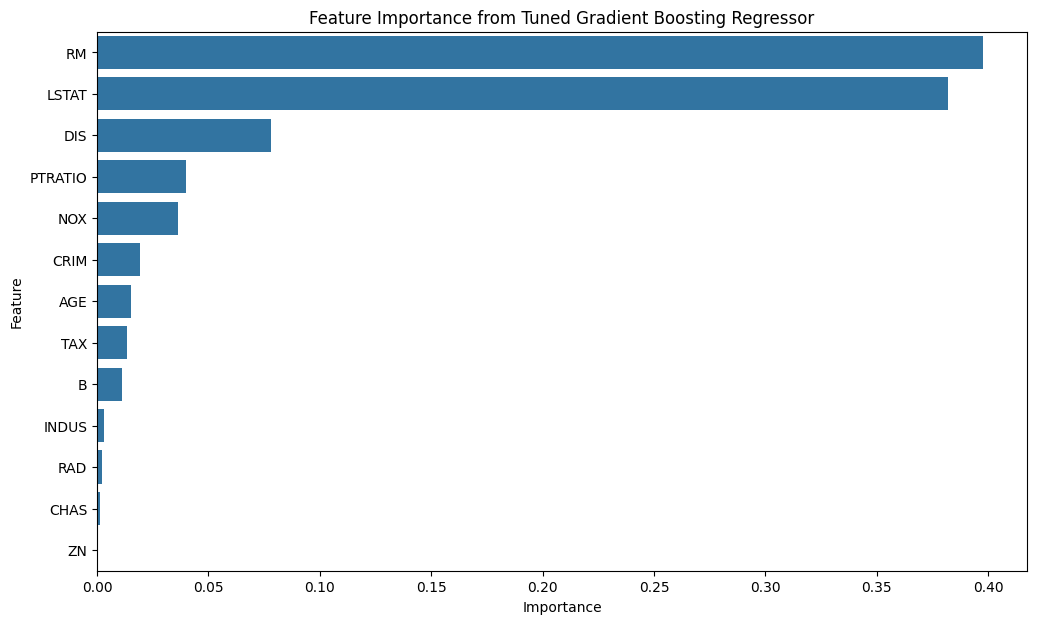

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get feature importances from the best Gradient Boosting Regressor model
feature_importances = best_random_gbr_model.feature_importances_

# Create a DataFrame for better visualization
features_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

# Sort features by importance
features_df = features_df.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=features_df)
plt.title('Feature Importance from Tuned Gradient Boosting Regressor')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [ ]:
import joblib

joblib.dump(best_random_gbr_model, "house_price_model.pkl")

['house_price_model.pkl']

## Phase 16: Predict New House Prices

In [ ]:
import joblib
import pandas as pd
import numpy as np

# Load the saved model
loaded_model = joblib.load('house_price_model.pkl')

print('Model loaded successfully!')

Model loaded successfully!


Now, let's create some hypothetical new house data. It's crucial that this new data has the same features (columns) and is preprocessed in the same way (scaled) as the data the model was trained on.

In [ ]:
# Create sample new house data (ensure it has the same columns as X)
# Using the mean of X as a base and slightly modifying some values
new_house_data = pd.DataFrame([
    {
        'CRIM': X['CRIM'].mean() * 0.5, 'ZN': X['ZN'].mean() * 1.2, 'INDUS': X['INDUS'].mean() * 0.8,
        'CHAS': 0, 'NOX': X['NOX'].mean() * 0.9, 'RM': X['RM'].mean() * 1.1,
        'AGE': X['AGE'].mean() * 0.7, 'DIS': X['DIS'].mean() * 1.3, 'RAD': X['RAD'].mean() * 0.5,
        'TAX': X['TAX'].mean() * 0.8, 'PTRATIO': X['PTRATIO'].mean() * 1.1, 'B': X['B'].mean() * 1.05,
        'LSTAT': X['LSTAT'].mean() * 0.6
    },
    {
        'CRIM': X['CRIM'].mean() * 1.5, 'ZN': X['ZN'].mean() * 0.5, 'INDUS': X['INDUS'].mean() * 1.2,
        'CHAS': 1, 'NOX': X['NOX'].mean() * 1.1, 'RM': X['RM'].mean() * 0.9,
        'AGE': X['AGE'].mean() * 1.1, 'DIS': X['DIS'].mean() * 0.8, 'RAD': X['RAD'].mean() * 1.5,
        'TAX': X['TAX'].mean() * 1.2, 'PTRATIO': X['PTRATIO'].mean() * 0.9, 'B': X['B'].mean() * 0.95,
        'LSTAT': X['LSTAT'].mean() * 1.4
    }
], columns=X.columns)

print("Original new house data:")
display(new_house_data)

# Scale the new house data using the SAME SCALER fitted on the training data
# The 'scaler' object should be available from previous steps
scaled_new_house_data = scaler.transform(new_house_data)

print("\nScaled new house data:")
display(pd.DataFrame(scaled_new_house_data, columns=X.columns))

# Predict prices for the new house data
predicted_prices = loaded_model.predict(scaled_new_house_data)

print("\nPredicted prices for new houses:")
for i, price in enumerate(predicted_prices):
    print(f"House {i+1}: ${price:.2f}K")

Original new house data:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,1.806762,13.636364,8.909423,0,0.499226,6.913098,48.002431,4.933555,4.774704,326.589723,20.301087,374.507733,7.591838
1,5.420285,5.681818,13.364134,1,0.610165,5.656171,75.432391,3.036034,14.324111,489.884585,16.609980,338.840330,17.714289



Scaled new house data:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,-0.203334,0.089391,-0.301424,-0.278089,-0.487064,0.842830,-0.735115,0.528689,-0.534058,-0.466614,0.890756,0.199330,-0.685132
1,0.204326,-0.254607,0.345492,3.595975,0.456626,-0.931054,0.245919,-0.362757,0.579045,0.517286,-0.767467,-0.190677,0.740249



Predicted prices for new houses:
House 1: $26.11K
House 2: $20.14K
